========== SECTION 1 ==========

In [65]:
import torch
import numpy as np

In [104]:
print ( " PyTorch Version : " , torch . __version__ )

 PyTorch Version :  2.11.0


In [67]:
device = torch . device ( 'cuda' if torch . cuda . is_available () else 'cpu')

In [117]:
X , Y = np . mgrid [ -4.0:4:0.01 , -4.0:4:0.01]
x = torch . Tensor ( X )
y = torch . Tensor ( Y )

# transfer to the GPU device
x = x . to ( device )
y = y . to ( device )

# Compute Gaussian
z = torch.sin( -( x **2 + y **2) /2.0)

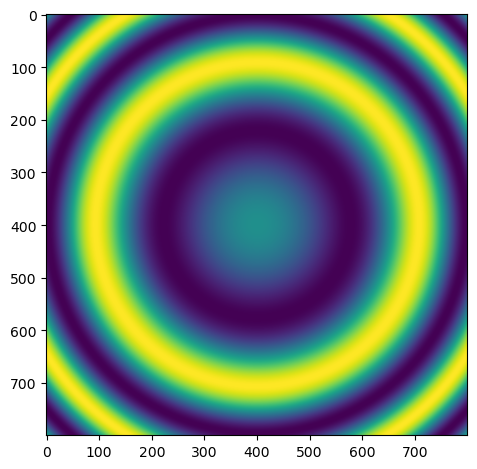

In [118]:
import matplotlib . pyplot as plt
plt . imshow ( z . cpu () . numpy () ) # Updated !
plt . tight_layout ()
plt . show ()

#

========== SECTION 2 ==========

In [ ]:
# Use NumPy to create a 2 D array of complex numbers on [ -2 ,2] x [ -2 ,2]
cx, cy = -0.7436, 0.1318   # centre
r = 0.0005              
n = 600                
step = 2*r/n

Y, X = np.mgrid[cy-r:cy+r:step, cx-r:cx+r:step]
# Y, X = np.mgrid[-1.3:1.3:0.001,  -2:1:0.001]

In [71]:
# reload into PyTorch tensors
x = torch . Tensor ( X )
y = torch . Tensor ( Y )
z = torch . complex (x , y ) # important !
zs = z . clone () # Updated !
ns = torch . zeros_like ( z )

#transfer to GPU
z = z . to ( device )
zs = zs . to ( device )
ns = ns . to ( device )

In [72]:
c = 7.0 + 23j

# Mandelbrot Set
for i in range (400) :
  # Compute the new values of z : z ^2 + x
  zs_ = zs * zs + z
  # Have we diverged with this new value ?
  not_diverged = torch . abs ( zs_ ) < 4.0
  # Update variables to compute
  ns += not_diverged
  zs = zs_

/var/folders/3w/zqdrwr112pz0d9qjjnzqcxs80000gn/T/ipykernel_24216/2491426444.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np . uint8 ( np . clip (a , 0 , 255) )


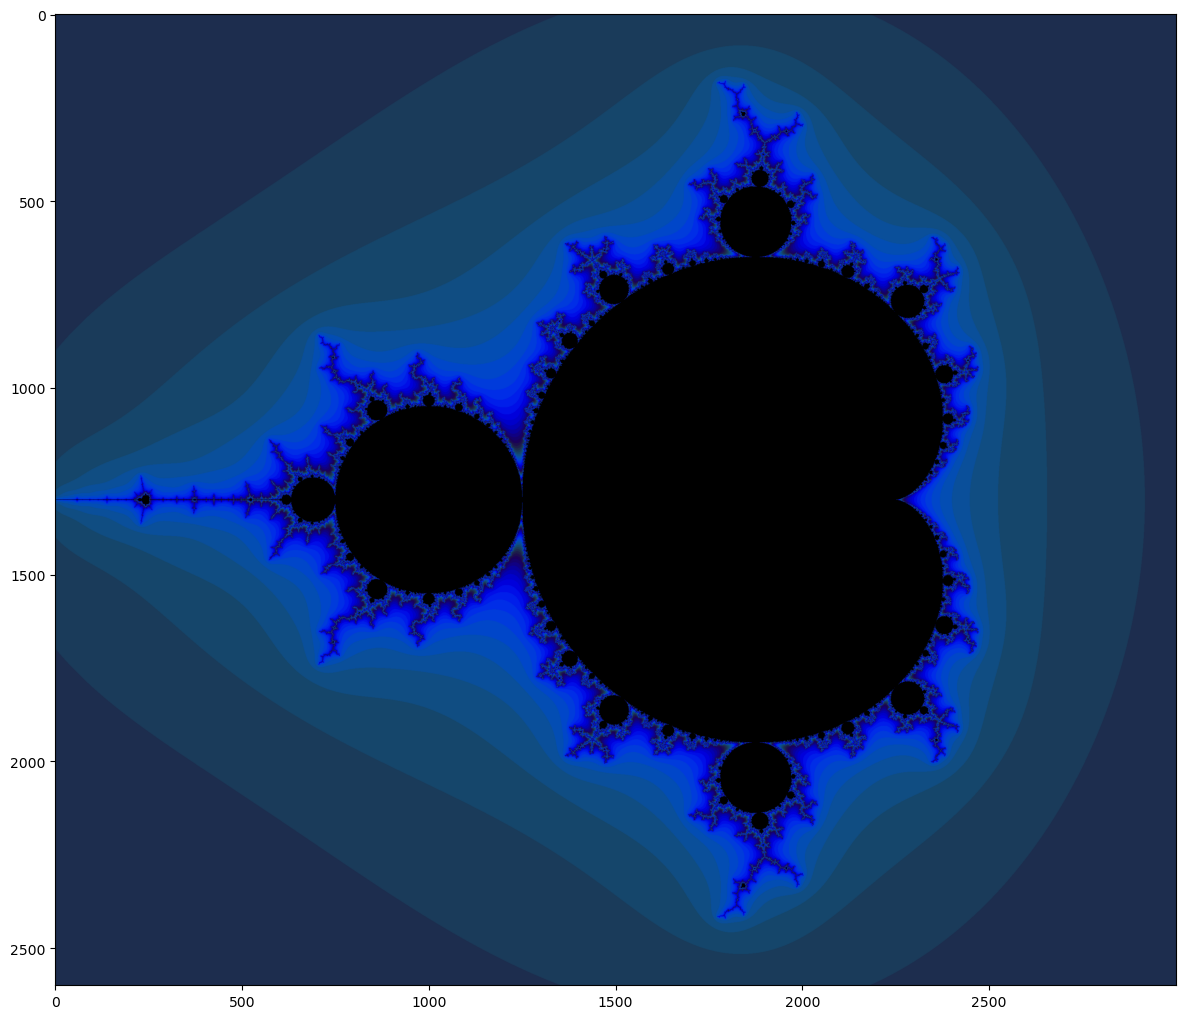

In [78]:
fig = plt . figure ( figsize =(12 ,10) )
def processFractal ( a ) :
  """ Display an array of iteration counts as a
  colorful picture of a fractal . """
  a_cyclic = (6.28* a /20.0) . reshape ( list ( a . shape ) +[1])
  img = np . concatenate ([10+20* np . cos ( a_cyclic ) ,
                          30+50* np . sin ( a_cyclic ) ,
                          155 -80* np . cos ( a_cyclic ) ] , 2)
  img [ a == a . max () ] = 0
  a = img
  a = np . uint8 ( np . clip (a , 0 , 255) )
  return a

plt . imshow ( processFractal ( ns . cpu () . numpy () ) )
plt . tight_layout ( pad =0)
plt . show ()

=========== Section 3 =============

I picked the gosper curve as my fractal. From the provided list at https://en.wikipedia.org/wiki/List_of_fractals_by_Hausdorff_dimension

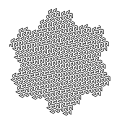

In [74]:
RULES = {'A': 'A-B--B+A++AA+B-', 'B': '+A-BB--B-A++A+B'}
# a and b -> move forward, + is turn left 60 degrees, - is turn right 60 degrees

In [108]:
def expand_to_order(rule_s: str, order: int):
  for _ in range(order):
    rule_s = ''.join(RULES.get(c, c) for c in rule_s)
  return rule_s

def draw_gosper(order):
  rule_s = expand_to_order('A', order)

  turns = torch.tensor([{'+': 1, '-': -1}.get (c, 0) for c in rule_s], device = device)
  dir = torch.cumsum(turns, 0)  * (torch.pi / 3) # get angle before each symbol
  draw = torch.tensor([c in 'AB' for c in rule_s], device=device)
  steps = torch.polar(torch.ones_like(dir), dir)[draw]
  points = torch.cat([torch.zeros(1, device = device), torch.cumsum(steps, 0)])
  return points



In [109]:
complexity = 5
points = draw_gosper(complexity)

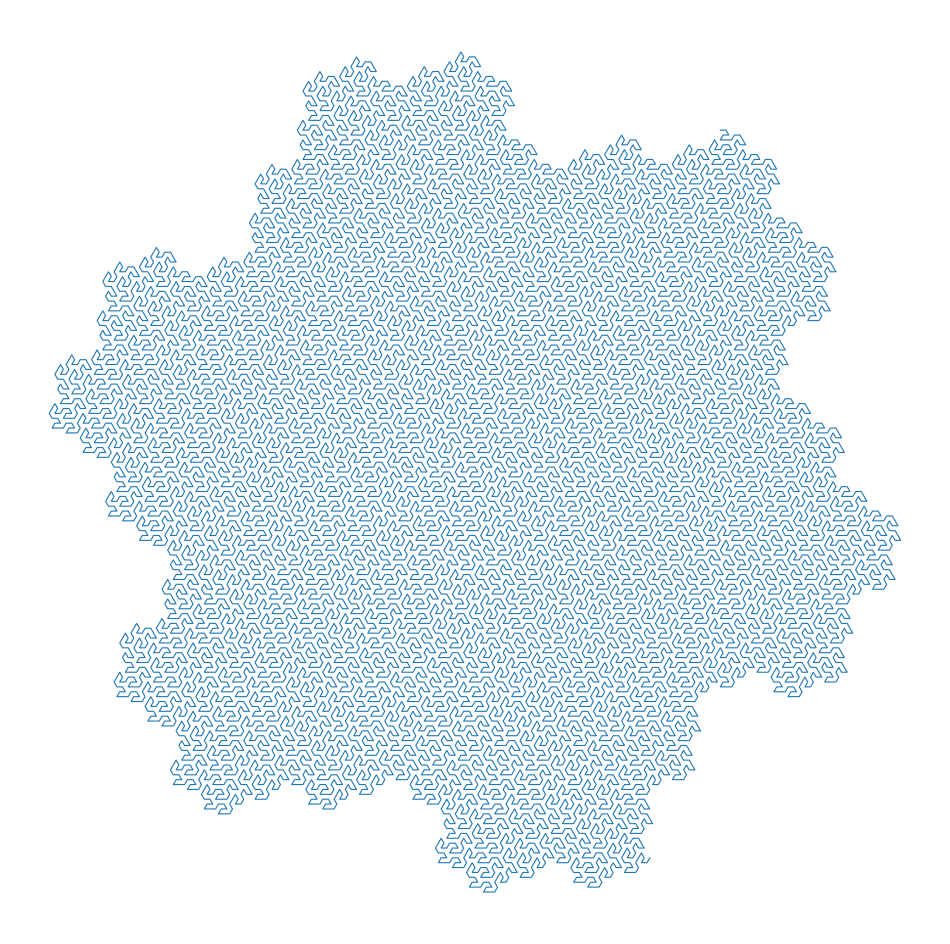

In [110]:
plt.figure(figsize=(12, 12))
plt.plot(points.real.cpu(), points.imag.cpu(), lw=0.8)
plt.axis('equal'); plt.axis('off')
plt.show()


#### AI Referencing

Claude Chat shared link -> https://claude.ai/share/e7b398da-0122-47ed-b3f4-497c59e44e2a









